# Arboles

## 🌳 1. Introducción a los Algoritmos de Clasificación

Los **algoritmos de clasificación** son técnicas de machine learning supervisado que predicen **categorías discretas**. Son fundamentales para:

- 🏥 **Diagnóstico médico** (enfermo/sano, tipo de enfermedad)
- 📧 **Detección de spam** (spam/no spam)
- 🎯 **Marketing dirigido** (compra/no compra)
- 🔒 **Detección de fraude** (fraudulento/legítimo)
- 📊 **Análisis de sentimientos** (positivo/negativo/neutral)

### Características Principales:
- **Variable objetivo**: Categórica (clase o etiqueta)
- **Predicción**: Probabilidad de pertenencia a cada clase
- **Evaluación**: Accuracy, Precision, Recall, F1-Score

In [1]:
# Librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Algoritmos de clasificación
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Utilidades de preprocessing y validación
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.datasets import make_classification, load_iris

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Visualización de árboles
from sklearn.tree import plot_tree
from sklearn import tree

import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.style.use('default')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 8)
np.random.seed(42)

## 🌲 2. Decision Trees (Árboles de Decisión)

Los **Decision Trees** son algoritmos que toman decisiones mediante una serie de preguntas binarias, creando una estructura similar a un árbol.

### 🔑 Conceptos Clave:

1. **Nodos**: Puntos de decisión (preguntas)
2. **Ramas**: Posibles respuestas (sí/no)
3. **Hojas**: Decisiones finales (clases)
4. **Criterios de división**: Gini, Entropy, Information Gain

### ✅ Ventajas:
- Fácil de interpretar y visualizar
- No requiere preprocesamiento de datos
- Maneja variables categóricas y numéricas
- Puede capturar relaciones no lineales

### ⚠️ Desventajas:
- Propenso al overfitting
- Inestable (pequeños cambios → árbol muy diferente)
- Sesgo hacia variables con más niveles

In [2]:
# Cargar dataset clásico para demostración
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = iris.target

print(f"- Muestras: {X_iris.shape[0]}")
print(f"- Features: {X_iris.shape[1]}")
print(f"- Clases: {len(np.unique(y_iris))}")
print(f"- Nombres de clases: {iris.target_names}")

# Visualizar las primeras filas
display(X_iris.head())

- Muestras: 150
- Features: 4
- Clases: 3
- Nombres de clases: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

print(f"🔄 División de datos:")
print(f"- Entrenamiento: {X_train.shape[0]} muestras")
print(f"- Prueba: {X_test.shape[0]} muestras")

# Crear y entrenar el Decision Tree
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,  # Limitamos la profundidad para evitar overfitting
    criterion='gini'  # Criterio de división
)

# Entrenar el modelo
dt_classifier.fit(X_train, y_train)

print("✅ Modelo Decision Tree entrenado")

🔄 División de datos:
- Entrenamiento: 105 muestras
- Prueba: 45 muestras
✅ Modelo Decision Tree entrenado


In [4]:
# Realizar predicciones
y_pred_dt = dt_classifier.predict(X_test)
y_pred_proba_dt = dt_classifier.predict_proba(X_test)

# Calcular métricas
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted')
recall_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')

print("🎯 Métricas del Decision Tree:")
print(f"- Accuracy: {accuracy_dt:.3f}")
print(f"- Precision: {precision_dt:.3f}")
print(f"- Recall: {recall_dt:.3f}")
print(f"- F1-Score: {f1_dt:.3f}")

🎯 Métricas del Decision Tree:
- Accuracy: 0.978
- Precision: 0.979
- Recall: 0.978
- F1-Score: 0.978


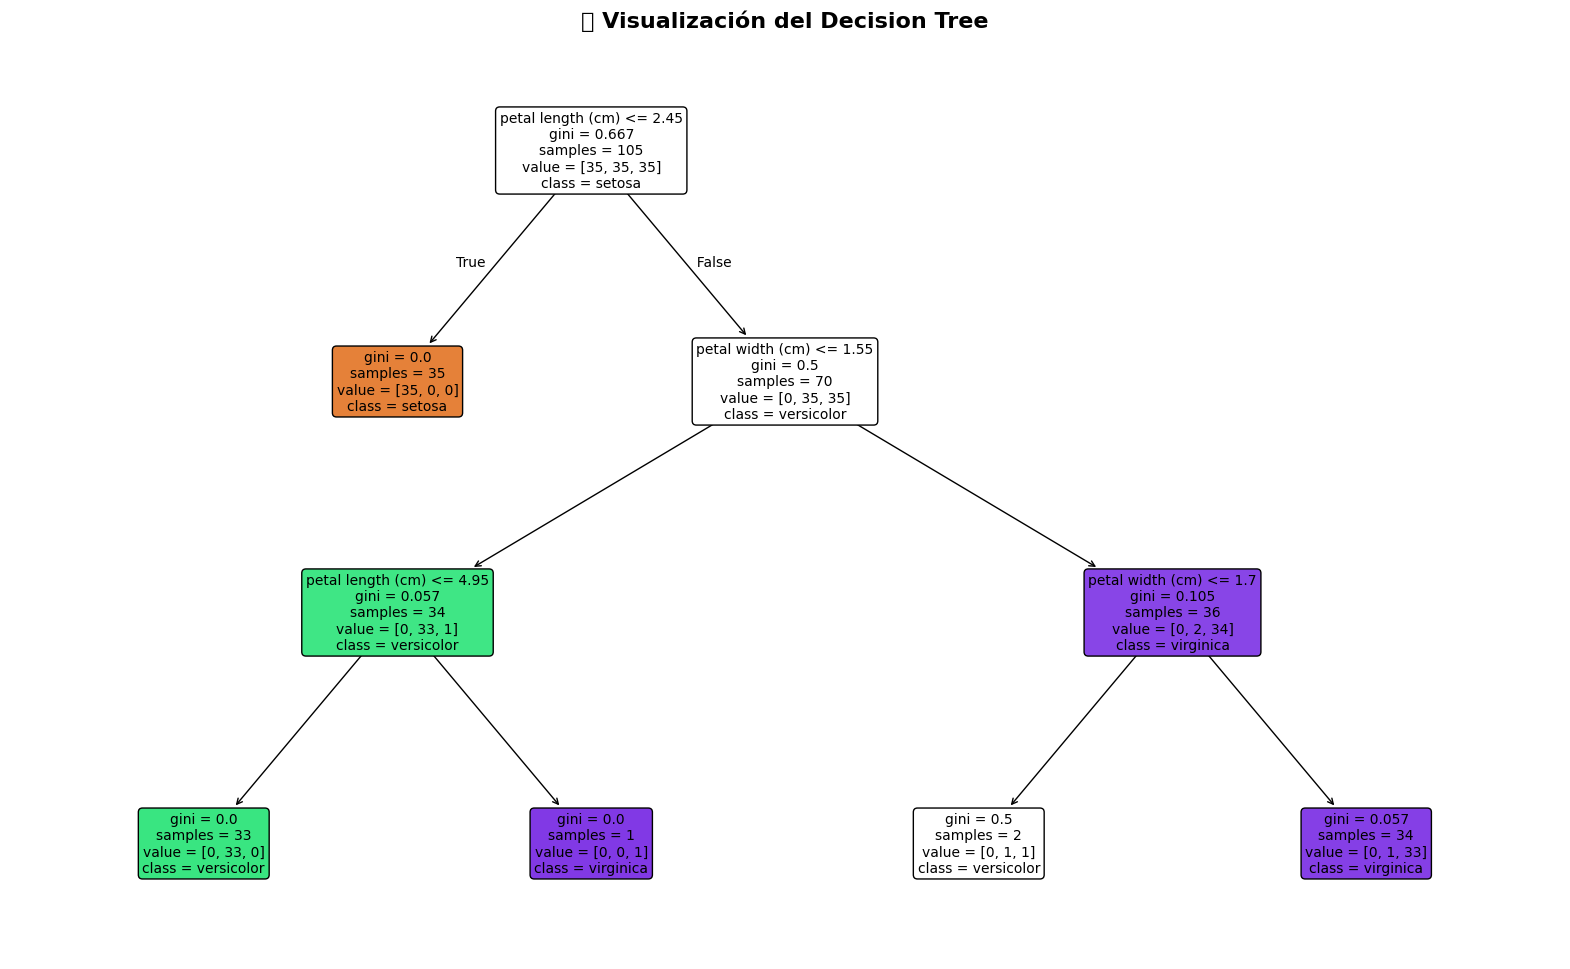

In [5]:
# Visualizar el árbol de decisión
plt.figure(figsize=(20, 12))
plot_tree(
    dt_classifier,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("🌳 Visualización del Decision Tree", fontsize=16, fontweight='bold')
plt.show()

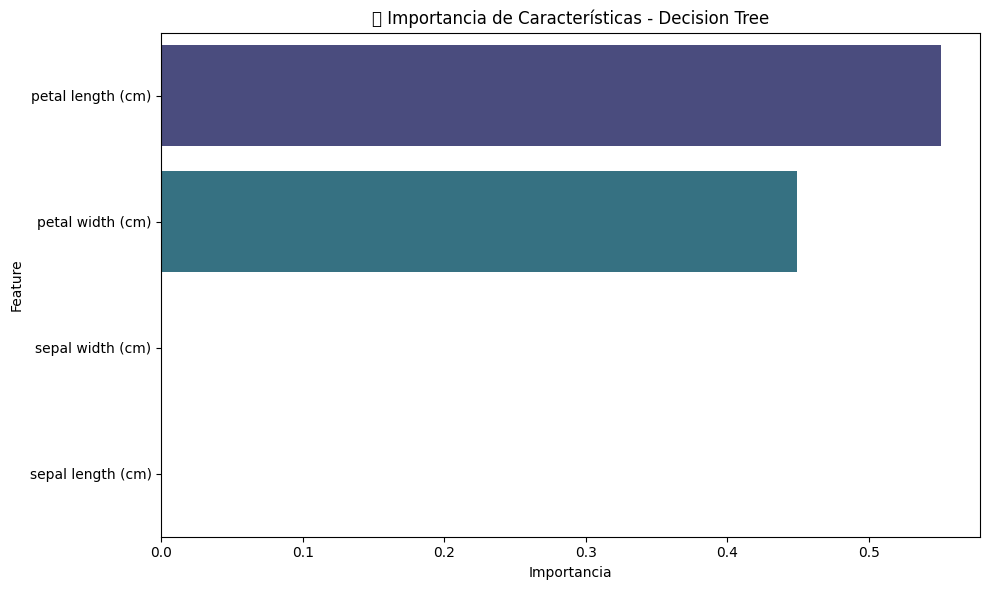

🔍 Importancia de características:


,Feature,Importance
2,petal length (cm),0.550877
3,petal width (cm),0.449123
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


In [6]:
# Importancia de las características
feature_importance_dt = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_dt, x='Importance', y='Feature', palette='viridis')
plt.title('📊 Importancia de Características - Decision Tree')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print("🔍 Importancia de características:")
display(feature_importance_dt)

## 🌳🌳 3. Random Forest (Bosques Aleatorios)

**Random Forest** es un algoritmo de **ensemble** que combina múltiples árboles de decisión para crear un modelo más robusto y preciso.

### 🔑 Conceptos Clave:

1. **Bagging**: Entrenar múltiples árboles con muestras aleatorias
2. **Feature Randomness**: Cada árbol usa un subconjunto aleatorio de características
3. **Votación**: La predicción final es el promedio/mayoría de todos los árboles
4. **Out-of-Bag (OOB)**: Estimación de error sin validación cruzada

### ✅ Ventajas:
- Reduce overfitting comparado con un solo árbol
- Más robusto y estable
- Maneja bien datos faltantes
- Proporciona importancia de características
- Excelente performance general

### ⚠️ Desventajas:
- Menos interpretable que un solo árbol
- Puede ser lento en datasets muy grandes
- Memoria intensivo

In [7]:
# Crear y entrenar Random Forest
rf_classifier = RandomForestClassifier(
    n_estimators=100,  # Número de árboles
    random_state=42,
    max_depth=3,      # Profundidad máxima de cada árbol
    min_samples_split=5,  # Mínimo de muestras para dividir un nodo
    min_samples_leaf=2,   # Mínimo de muestras en una hoja
    bootstrap=True,       # Usar bootstrap sampling
    oob_score=True       # Calcular OOB score
)

# Entrenar el modelo
rf_classifier.fit(X_train, y_train)

print("✅ Modelo Random Forest entrenado")
print(f"🎯 OOB Score: {rf_classifier.oob_score_:.3f}")

✅ Modelo Random Forest entrenado
🎯 OOB Score: 0.952


In [8]:
# Realizar predicciones con Random Forest
y_pred_rf = rf_classifier.predict(X_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test)

# Calcular métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("🎯 Métricas del Random Forest:")
print(f"- Accuracy: {accuracy_rf:.3f}")
print(f"- Precision: {precision_rf:.3f}")
print(f"- Recall: {recall_rf:.3f}")
print(f"- F1-Score: {f1_rf:.3f}")

🎯 Métricas del Random Forest:
- Accuracy: 0.911
- Precision: 0.916
- Recall: 0.911
- F1-Score: 0.911


🏆 Comparación de Modelos:


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.977778,0.979167,0.977778,0.977753
1,Random Forest,0.911111,0.915535,0.911111,0.910714


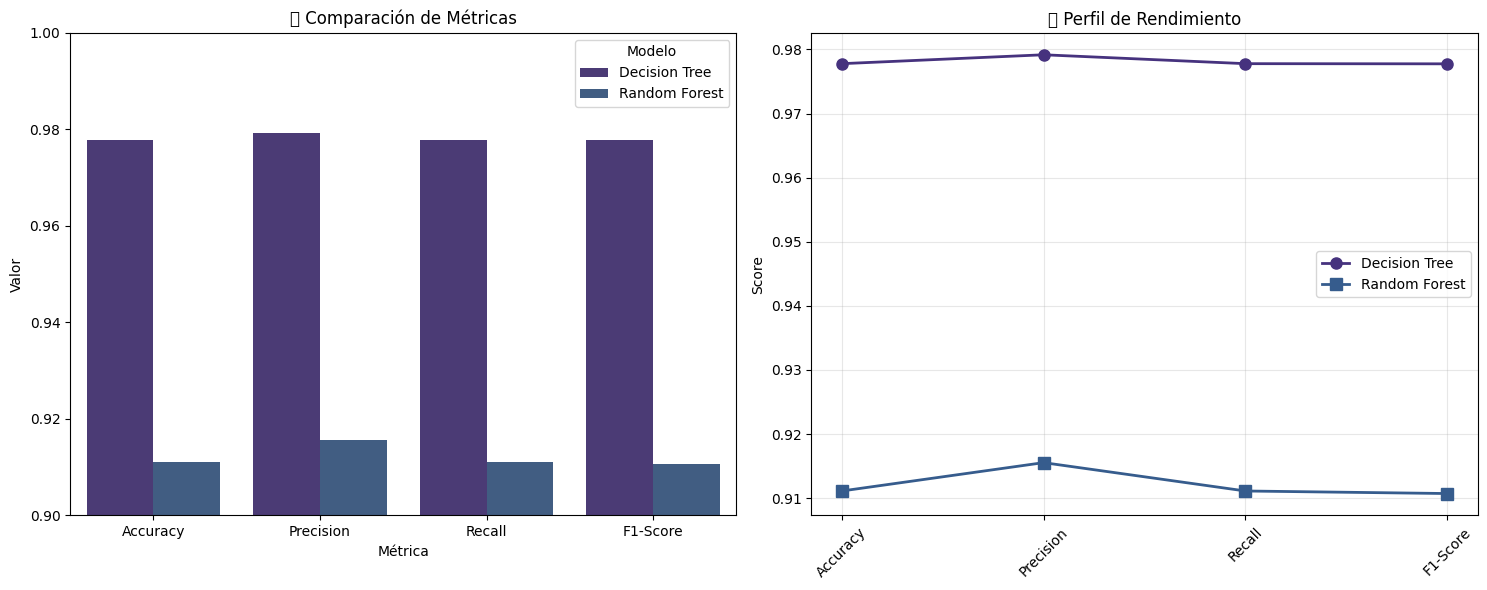

In [9]:
# Comparar modelos
comparison_df = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_dt, accuracy_rf],
    'Precision': [precision_dt, precision_rf],
    'Recall': [recall_dt, recall_rf],
    'F1-Score': [f1_dt, f1_rf]
})

print("🏆 Comparación de Modelos:")
display(comparison_df)

# Visualizar comparación
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
comparison_melted = comparison_df.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
sns.barplot(data=comparison_melted, x='Métrica', y='Valor', hue='Modelo', ax=ax[0])
ax[0].set_title('📊 Comparación de Métricas')
ax[0].set_ylim(0.9, 1.0)

# Gráfico radar sería ideal, pero haremos un line plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
dt_values = [accuracy_dt, precision_dt, recall_dt, f1_dt]
rf_values = [accuracy_rf, precision_rf, recall_rf, f1_rf]

ax[1].plot(metrics, dt_values, 'o-', label='Decision Tree', linewidth=2, markersize=8)
ax[1].plot(metrics, rf_values, 's-', label='Random Forest', linewidth=2, markersize=8)
ax[1].set_title('📈 Perfil de Rendimiento')
ax[1].set_ylabel('Score')
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

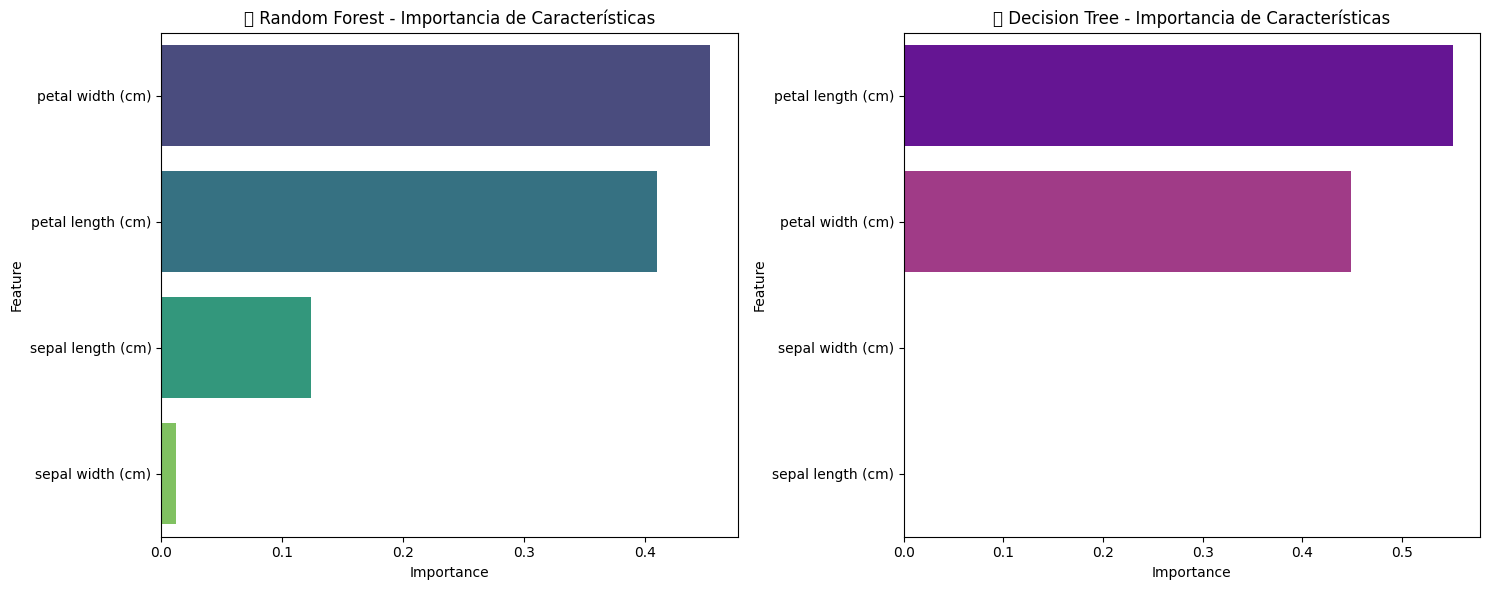

🔍 Comparación de importancia de características:

🌳 Random Forest:


,Feature,Importance
3,petal width (cm),0.454047
2,petal length (cm),0.409737
0,sepal length (cm),0.124052
1,sepal width (cm),0.012164



🌲 Decision Tree:


,Feature,Importance
2,petal length (cm),0.550877
3,petal width (cm),0.449123
1,sepal width (cm),0.000000
0,sepal length (cm),0.000000


In [10]:
# Importancia de características en Random Forest
feature_importance_rf = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest
sns.barplot(data=feature_importance_rf, x='Importance', y='Feature', 
           palette='viridis', ax=ax1)
ax1.set_title('🌳 Random Forest - Importancia de Características')

# Decision Tree
sns.barplot(data=feature_importance_dt, x='Importance', y='Feature', 
           palette='plasma', ax=ax2)
ax2.set_title('🌲 Decision Tree - Importancia de Características')

plt.tight_layout()
plt.show()

print("🔍 Comparación de importancia de características:")
print("\n🌳 Random Forest:")
display(feature_importance_rf)
print("\n🌲 Decision Tree:")
display(feature_importance_dt)

## 📊 4. Análisis Profundo con Dataset de Advertising

Ahora vamos a aplicar nuestros conocimientos con un dataset más complejo y realista.

In [11]:
# Cargar dataset de Advertising
df_ads = pd.read_csv('../../data/src/Advertising.csv')

print("📊 Dataset de Advertising:")
print(f"- Filas: {df_ads.shape[0]}")
print(f"- Columnas: {df_ads.shape[1]}")

display(df_ads.head())
display(df_ads.info())

📊 Dataset de Advertising:
- Filas: 200
- Columnas: 4


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


None

In [12]:
# Crear variable objetivo para clasificación
# Convertir 'Sales' en una variable categórica
# Alto: Sales > percentil 75, Medio: percentil 25-75, Bajo: < percentil 25

sales_q25 = df_ads['Sales'].quantile(0.25)
sales_q75 = df_ads['Sales'].quantile(0.75)

def categorize_sales(sales):
    if sales < sales_q25:
        return 'Bajo'
    elif sales > sales_q75:
        return 'Alto'
    else:
        return 'Medio'

df_ads['Sales_Category'] = df_ads['Sales'].apply(categorize_sales)

print("🎯 Distribución de categorías de ventas:")
print(df_ads['Sales_Category'].value_counts())

# Preparar datos para clasificación
X_ads = df_ads[['TV', 'Radio', 'Newspaper']]
y_ads = df_ads['Sales_Category']

# Codificar las etiquetas
le = LabelEncoder()
y_ads_encoded = le.fit_transform(y_ads)

print(f"\n🔄 Mapeo de etiquetas:")
for i, label in enumerate(le.classes_):
    print(f"- {label}: {i}")

🎯 Distribución de categorías de ventas:
Sales_Category
Medio    101
Alto      50
Bajo      49
Name: count, dtype: int64

🔄 Mapeo de etiquetas:
- Alto: 0
- Bajo: 1
- Medio: 2


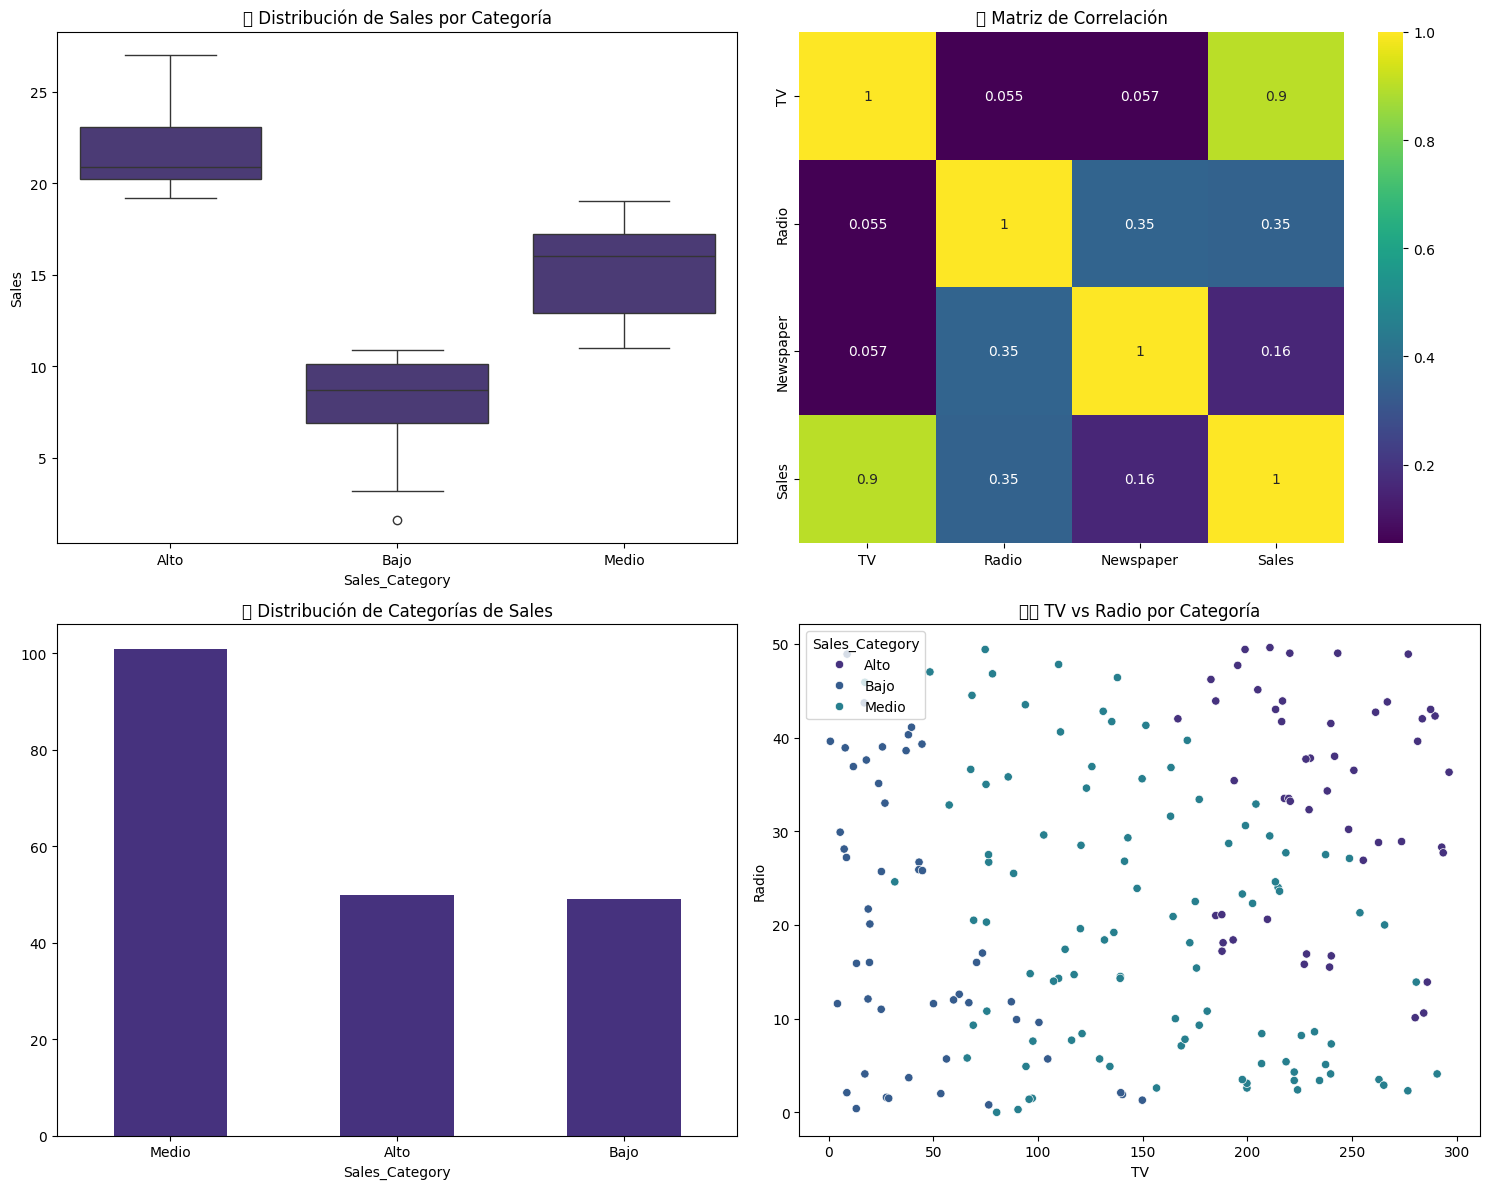

In [13]:
# Exploración visual del dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribución de Sales por categoría
sns.boxplot(data=df_ads, x='Sales_Category', y='Sales', ax=axes[0,0])
axes[0,0].set_title('📊 Distribución de Sales por Categoría')

# Correlación entre features y sales
correlation_matrix = df_ads[['TV', 'Radio', 'Newspaper', 'Sales']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', ax=axes[0,1])
axes[0,1].set_title('🔥 Matriz de Correlación')

# Distribución de las categorías
df_ads['Sales_Category'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('📈 Distribución de Categorías de Sales')
axes[1,0].tick_params(axis='x', rotation=0)

# Pairplot simplificado para una feature
sns.scatterplot(data=df_ads, x='TV', y='Radio', hue='Sales_Category', ax=axes[1,1])
axes[1,1].set_title('📺📻 TV vs Radio por Categoría')

plt.tight_layout()
plt.show()

In [14]:
# División de datos para Advertising
X_train_ads, X_test_ads, y_train_ads, y_test_ads = train_test_split(
    X_ads, y_ads_encoded, test_size=0.3, random_state=42, stratify=y_ads_encoded
)

print(f"🔄 División de datos Advertising:")
print(f"- Entrenamiento: {X_train_ads.shape[0]} muestras")
print(f"- Prueba: {X_test_ads.shape[0]} muestras")

# Entrenar ambos modelos
print("\n🚀 Entrenando modelos...")

# Decision Tree
dt_ads = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_ads.fit(X_train_ads, y_train_ads)

# Random Forest
rf_ads = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_ads.fit(X_train_ads, y_train_ads)

print("✅ Modelos entrenados correctamente")

🔄 División de datos Advertising:
- Entrenamiento: 140 muestras
- Prueba: 60 muestras

🚀 Entrenando modelos...
✅ Modelos entrenados correctamente


In [15]:
# Evaluación completa en dataset Advertising
y_pred_dt_ads = dt_ads.predict(X_test_ads)
y_pred_rf_ads = rf_ads.predict(X_test_ads)

print("🎯 RESULTADOS EN DATASET ADVERTISING\n")

# Decision Tree
print("🌲 Decision Tree:")
print(f"- Accuracy: {accuracy_score(y_test_ads, y_pred_dt_ads):.3f}")
print(f"- Precision: {precision_score(y_test_ads, y_pred_dt_ads, average='weighted'):.3f}")
print(f"- Recall: {recall_score(y_test_ads, y_pred_dt_ads, average='weighted'):.3f}")
print(f"- F1-Score: {f1_score(y_test_ads, y_pred_dt_ads, average='weighted'):.3f}")

print("\n🌳 Random Forest:")
print(f"- Accuracy: {accuracy_score(y_test_ads, y_pred_rf_ads):.3f}")
print(f"- Precision: {precision_score(y_test_ads, y_pred_rf_ads, average='weighted'):.3f}")
print(f"- Recall: {recall_score(y_test_ads, y_pred_rf_ads, average='weighted'):.3f}")
print(f"- F1-Score: {f1_score(y_test_ads, y_pred_rf_ads, average='weighted'):.3f}")

🎯 RESULTADOS EN DATASET ADVERTISING

🌲 Decision Tree:
- Accuracy: 0.733
- Precision: 0.735
- Recall: 0.733
- F1-Score: 0.733

🌳 Random Forest:
- Accuracy: 0.783
- Precision: 0.796
- Recall: 0.783
- F1-Score: 0.779


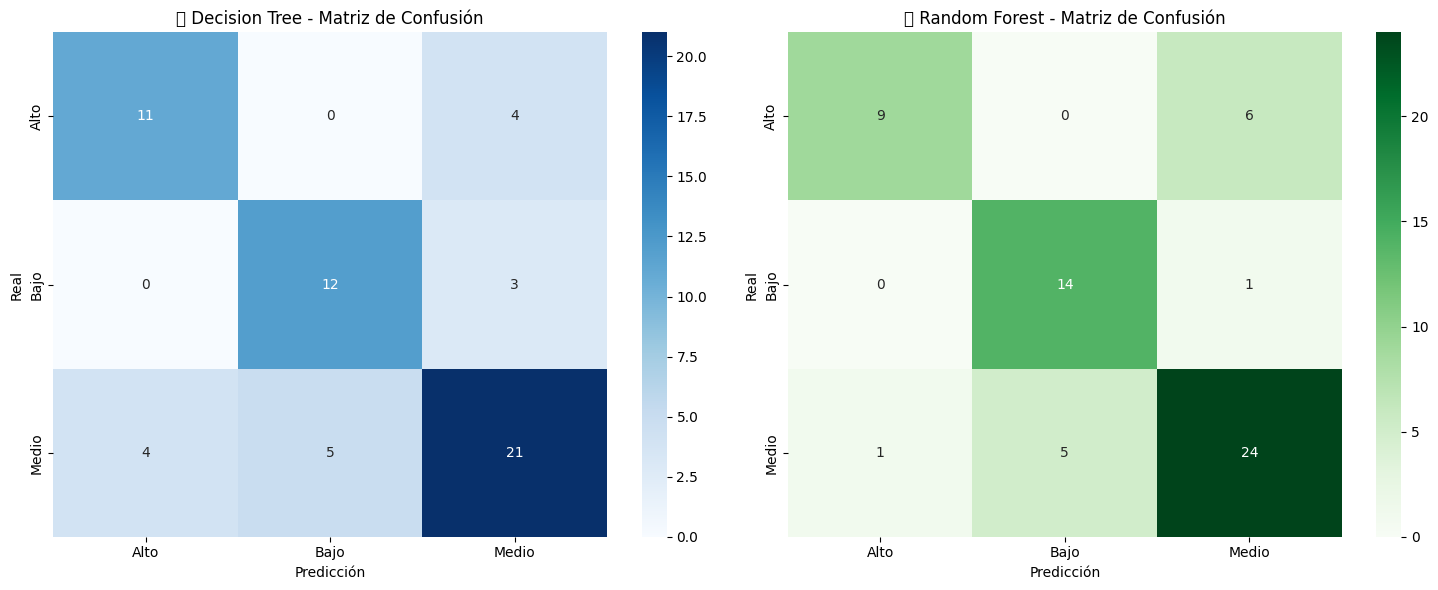

In [16]:
# Matrices de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Decision Tree
cm_dt = confusion_matrix(y_test_ads, y_pred_dt_ads)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', 
           xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('🌲 Decision Tree - Matriz de Confusión')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')

# Random Forest
cm_rf = confusion_matrix(y_test_ads, y_pred_rf_ads)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
           xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('🌳 Random Forest - Matriz de Confusión')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')

plt.tight_layout()
plt.show()

In [17]:
# Reportes de clasificación detallados
print("📋 REPORTES DETALLADOS DE CLASIFICACIÓN\n")

print("🌲 Decision Tree:")
print(classification_report(y_test_ads, y_pred_dt_ads, target_names=le.classes_))

print("\n🌳 Random Forest:")
print(classification_report(y_test_ads, y_pred_rf_ads, target_names=le.classes_))

📋 REPORTES DETALLADOS DE CLASIFICACIÓN

🌲 Decision Tree:
              precision    recall  f1-score   support

        Alto       0.73      0.73      0.73        15
        Bajo       0.71      0.80      0.75        15
       Medio       0.75      0.70      0.72        30

    accuracy                           0.73        60
   macro avg       0.73      0.74      0.74        60
weighted avg       0.73      0.73      0.73        60


🌳 Random Forest:
              precision    recall  f1-score   support

        Alto       0.90      0.60      0.72        15
        Bajo       0.74      0.93      0.82        15
       Medio       0.77      0.80      0.79        30

    accuracy                           0.78        60
   macro avg       0.80      0.78      0.78        60
weighted avg       0.80      0.78      0.78        60



## 🎛️ 5. Hiperparámetros y Optimización

Los hiperparámetros son configuraciones que controlamos antes del entrenamiento y que afectan significativamente el rendimiento del modelo.

🔧 ANÁLISIS DE HIPERPARÁMETROS



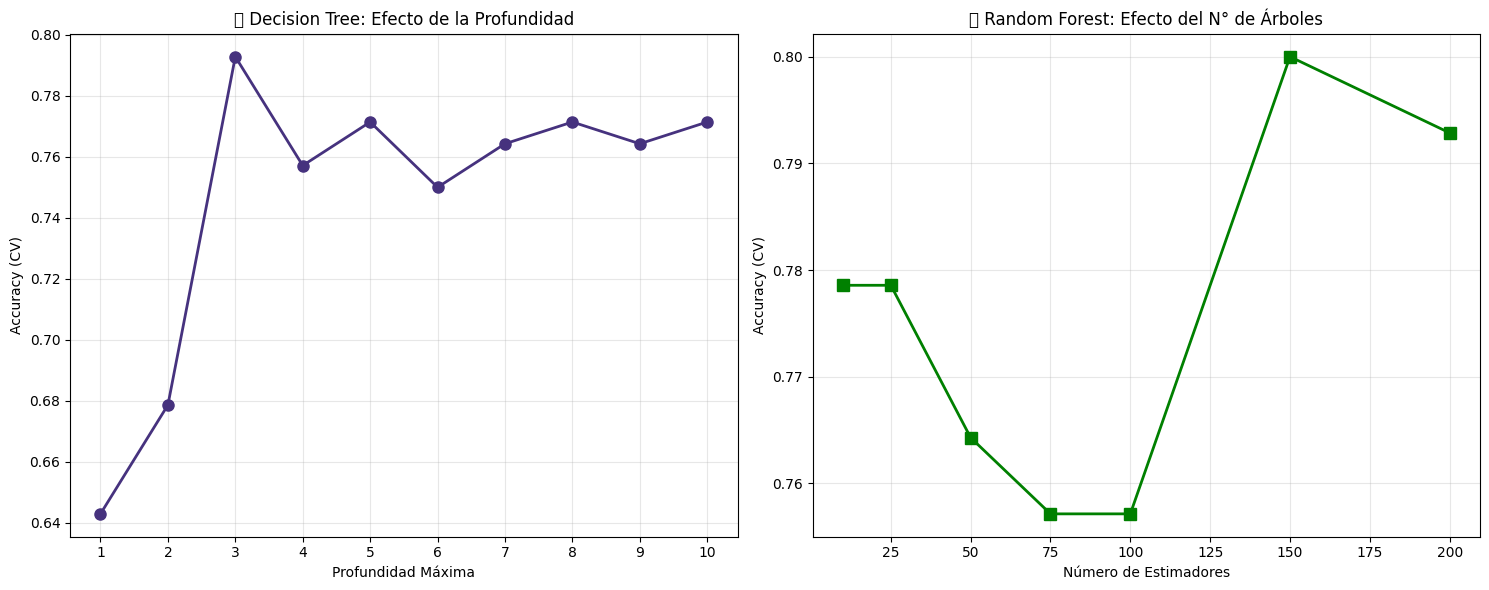

🎯 Mejor profundidad para DT: 3 (Accuracy: 0.793)
🎯 Mejor n_estimators para RF: 150 (Accuracy: 0.800)


In [18]:
# Análisis del efecto de diferentes hiperparámetros
print("🔧 ANÁLISIS DE HIPERPARÁMETROS\n")

# Probar diferentes profundidades para Decision Tree
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
dt_scores = []

for depth in depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt_temp, X_train_ads, y_train_ads, cv=5)
    dt_scores.append(scores.mean())

# Probar diferentes números de estimadores para Random Forest
n_estimators_list = [10, 25, 50, 75, 100, 150, 200]
rf_scores = []

for n_est in n_estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n_est, max_depth=5, random_state=42)
    scores = cross_val_score(rf_temp, X_train_ads, y_train_ads, cv=5)
    rf_scores.append(scores.mean())

# Visualizar resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Decision Tree - Profundidad
ax1.plot(depths, dt_scores, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Profundidad Máxima')
ax1.set_ylabel('Accuracy (CV)')
ax1.set_title('🌲 Decision Tree: Efecto de la Profundidad')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(depths)

# Random Forest - Número de estimadores
ax2.plot(n_estimators_list, rf_scores, 's-', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Número de Estimadores')
ax2.set_ylabel('Accuracy (CV)')
ax2.set_title('🌳 Random Forest: Efecto del N° de Árboles')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"🎯 Mejor profundidad para DT: {depths[np.argmax(dt_scores)]} (Accuracy: {max(dt_scores):.3f})")
print(f"🎯 Mejor n_estimators para RF: {n_estimators_list[np.argmax(rf_scores)]} (Accuracy: {max(rf_scores):.3f})")

## 🎓 6. Interpretación y Casos de Uso

### 🔍 ¿Cuándo usar Decision Trees?
- **Interpretabilidad es clave**: Necesitas explicar decisiones
- **Datos categóricos**: Maneja naturalmente variables categóricas
- **Reglas simples**: Quieres reglas if-then claras
- **Prototipado rápido**: Baseline rápido para entender datos

### 🔍 ¿Cuándo usar Random Forest?
- **Accuracy es prioridad**: Necesitas el mejor rendimiento
- **Datos complejos**: Múltiples tipos de variables
- **Robustez**: Datos con ruido o outliers
- **Feature selection**: Identificar variables importantes
- **Producción**: Modelos estables y confiables

### 🚀 Mejores Prácticas:
1. **Validación cruzada** siempre para hiperparámetros
2. **Controlar overfitting** con max_depth, min_samples_split
3. **Balancear clases** si hay desbalance
4. **Feature engineering** puede mejorar mucho el rendimiento
5. **Ensemble methods** combinan lo mejor de ambos mundos

In [19]:
# Ejemplo práctico: Sistema de recomendación de inversión publicitaria
print("💼 CASO PRÁCTICO: SISTEMA DE RECOMENDACIÓN DE INVERSIÓN PUBLICITARIA\n")

def predict_sales_strategy(tv, radio, newspaper, model_type='rf'):
    """
    Predice la estrategia de ventas basada en inversión publicitaria
    """
    # Preparar datos
    input_data = np.array([[tv, radio, newspaper]])
    
    # Seleccionar modelo
    if model_type == 'rf':
        model = rf_ads
        model_name = "Random Forest"
    else:
        model = dt_ads
        model_name = "Decision Tree"
    
    # Hacer predicción
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    
    # Convertir predicción a etiqueta
    category = le.inverse_transform([prediction])[0]
    
    print(f"🤖 Modelo utilizado: {model_name}")
    print(f"📺 TV: ${tv}k, 📻 Radio: ${radio}k, 📰 Newspaper: ${newspaper}k")
    print(f"🎯 Predicción: {category}")
    print(f"📊 Probabilidades:")
    
    for i, prob in enumerate(probabilities):
        label = le.inverse_transform([i])[0]
        print(f"   - {label}: {prob:.3f}")
    
    return category, probabilities

# Ejemplos de predicción
print("📋 EJEMPLOS DE PREDICCIÓN:\n")

# Caso 1: Alta inversión en TV
print("🔸 Caso 1: Alta inversión en TV")
predict_sales_strategy(250, 50, 25)

print("\n" + "="*50 + "\n")

# Caso 2: Inversión balanceada
print("🔸 Caso 2: Inversión balanceada")
predict_sales_strategy(150, 100, 75)

print("\n" + "="*50 + "\n")

# Caso 3: Baja inversión general
print("🔸 Caso 3: Baja inversión general")
predict_sales_strategy(50, 25, 10)

💼 CASO PRÁCTICO: SISTEMA DE RECOMENDACIÓN DE INVERSIÓN PUBLICITARIA

📋 EJEMPLOS DE PREDICCIÓN:

🔸 Caso 1: Alta inversión en TV
🤖 Modelo utilizado: Random Forest
📺 TV: $250k, 📻 Radio: $50k, 📰 Newspaper: $25k
🎯 Predicción: Alto
📊 Probabilidades:
   - Alto: 0.835
   - Bajo: 0.012
   - Medio: 0.153


🔸 Caso 2: Inversión balanceada
🤖 Modelo utilizado: Random Forest
📺 TV: $150k, 📻 Radio: $100k, 📰 Newspaper: $75k
🎯 Predicción: Medio
📊 Probabilidades:
   - Alto: 0.345
   - Bajo: 0.082
   - Medio: 0.573


🔸 Caso 3: Baja inversión general
🤖 Modelo utilizado: Random Forest
📺 TV: $50k, 📻 Radio: $25k, 📰 Newspaper: $10k
🎯 Predicción: Bajo
📊 Probabilidades:
   - Alto: 0.023
   - Bajo: 0.777
   - Medio: 0.200


('Bajo', array([0.02294192, 0.77692559, 0.20013248]))